# Fabrikskapacitet vs. gennemløb: Todimensional porteføljeanalyse med PROC SGPLOT


## Resumé

En produktionsportefølje inden for diskret fremstilling har to tal, der betyder noget for hver produktlinje på samme tid: **hvor meget maskinkapacitet den forbruger** og **hvor meget godt output den faktisk leverer**. Et endimensionalt søjlediagram kan kun vise ét af dem. Denne notebook visualiserer begge sammen med `PROC SGPLOT`, ved brug af et **boble-plot** som kernevisning — hver linje placeres efter kapacitet (x) og gennemløb (y), hvor boblestørrelsen kodes efter dens produktivitetsrate (enheder pr. maskintime). Linjer, der ligger lavt og til højre (meget kapacitet, lidt output), er kapacitetsdræn; linjer, der ligger højt og til venstre med en stor boble, er højtydende. En grupperet søjlevisning nedbryder derefter gennemløbet efter fabrik, og en produktivitetsrangering bekræfter forskellen.

Med udgangspunkt i det faktisk udførte output (otte produktlinjer på tværs af tre fabrikker, 100 kørsler på vagtniveau aggregeret til 24 linje-fabrik-celler) viser analysen, at **Støbning** er porteføljens klareste kapacitetsdræn (14.3 gode enheder pr. maskintime — den trækker 10.1% af den samlede kapacitet, men leverer kun 3.2% af de gode enheder), mens **Emballering** er den mest fremtrædende højtydende linje (119.2 enheder pr. time — 9.1% af kapaciteten returnerer 23.8% af outputtet). På tværs af fabrikker kører **Stuttgart** varmest med 49.9 enheder/time, og **Monterrey** koldest med 41.6.

## Datakilder

| Kilde | Beskrivelse | Poster |
|--------|-------------|--------|
| WORK.PRODUCTION_RUNS | Syntetiske produktionskørsler på vagtniveau på tværs af 8 produktlinjer, 3 fabrikker og 3 vagter — planlagte maskintimer, kørselstimer, nedetid, brutto-/kasserede/gode enheder (begrænset til 100 observationer i ulicenseret tilstand) | 100 |
| WORK.LINE_CAPACITY | Aggregeret opsummering pr. produktlinje og fabrik: samlede kapacitetstimer (x), producerede gode enheder (y), og godkendt-enheds-udbytte % | 24 |

*Alle data er syntetiske og genereret direkte i notebooken med en fast seed — ingen eksterne filer, intet netværk.*

# Analyse af fabrikskapacitet vs. gennemløb

**Domæne:** Diskret fremstilling — drift / produktionsteknik

**Procedure:** `PROC SGPLOT` (ODS Statistical Graphics)

Et konventionelt søjlediagram viser kun én respons pr. kategori. For at sammenligne en produktionsportefølje på **to** numeriske dimensioner samtidig — *hvor meget kapacitet hver produktlinje forbruger* over for *hvor meget output den faktisk leverer* — har vi brug for et plot, der placerer begge på samme lærred. `PROC SGPLOT`s `BUBBLE`-sætning gør netop det: den placerer hver linje efter kapacitet (x) og gode enheder (y) og lader et tredje mål, produktivitetsraten, styre boblestørrelsen. En linje, der ligger langt til højre, men lavt, er et kapacitetsdræn; en linje, der ligger højt og til venstre med en fed boble, er en højtydende linje, det er værd at beskytte. Denne notebook opbygger et realistisk syntetisk produktionsdatasæt og driver SGPLOT gennem et boble-plot, et fabriksgrupperet søjlediagram, en enkelt-fabriks-drill-down og en side-om-side klyngefabrikssammenligning.

> **En bemærkning om PROC GAREABAR.** Den klassiske SAS/GRAPH-måde at kode to dimensioner pr. *søjle* er `PROC GAREABAR` (et rent ActiveX-arealsøjlediagram, hvor søjlebredden koder én variabel og højden en anden). GAREABAR er **endnu ikke implementeret i denne Jenner-build** — hullet spores af den bankede test `tests/400996_nb_gareabar_unimplemented`. Denne notebook når det samme analytiske mål med det fuldt understøttede `PROC SGPLOT`, hvis boble- og grupperet-søjle-visninger formidler den identiske kapacitet-vs-gennemløb-historie.

## 1. Generér syntetiske produktionsdata

Vi simulerer seks ugers produktionskørsler på vagtniveau for et netværk med tre fabrikker inden for diskret fremstilling. Hver produktlinje har en grundlæggende cyklustid og kasseringsrate; gennemløbet drives af planlagte maskintimer, linjespecifik effektivitet og tilfældig nedetid. `call streaminit` fastsætter seeden, så notebooken er fuldt reproducerbar — ingen eksterne filer, intet netværk.

In [1]:
/* --------------------------------------------------------
   Synthetic shift-level production runs
   8 product lines x 3 plants x 3 shifts x ~10 days
   width var  = scheduled machine-hours (capacity)
   response   = good units produced  (throughput)
   -------------------------------------------------------- */
data work.production_runs;
    CALL streaminit(20260531);
    LÆNGDE product_line $20 plant $12 shift $8;

    /* nominal units produced per machine-hour, by line */
    TABEL line_rate[8] _temporary_
        (42 28 35 18 60 75 90 140);
    /* base scrap fraction by line */
    TABEL line_scrap[8] _temporary_
        (0.04 0.06 0.05 0.09 0.03 0.02 0.02 0.01);
    TABEL plant_names[3] $12 _temporary_
        ('Detroit' 'Monterrey' 'Stuttgart');
    /* plant efficiency multiplier */
    TABEL plant_eff[3] _temporary_ (1.00 0.92 1.08);
    TABEL shift_names[3] $8 _temporary_ ('Dag' 'Aften' 'Nat');
    TABEL shift_eff[3] _temporary_ (1.00 0.95 0.88);

    GØR day = 1 TIL 10;
        GØR li = 1 TIL 8;
            GØR pi = 1 TIL 3;
                GØR si = 1 TIL 3;
                    HVIS li = 1 SÅ product_line = "Stansning";
                    ELLERS HVIS li = 2 SÅ product_line = "Svejsning";
                    ELLERS HVIS li = 3 SÅ product_line = "Bearbejdning";
                    ELLERS HVIS li = 4 SÅ product_line = "Støbning";
                    ELLERS HVIS li = 5 SÅ product_line = "Sprøjtestøbning";
                    ELLERS HVIS li = 6 SÅ product_line = "Samling";
                    ELLERS HVIS li = 7 SÅ product_line = "Efterbehandling";
                    ELLERS product_line = "Emballering";
                    plant        = plant_names[pi];
                    shift        = shift_names[si];

                    /* scheduled machine-hours for the shift */
                    sched_hours = round(6.5 + rand('uniform') * 1.5, 0.1);

                    /* unplanned downtime eats into capacity */
                    downtime_hours =
                        round(rand('uniform') * 1.2
                              * (2 - plant_eff[pi]), 0.1);
                    run_hours = MAX(sched_hours - downtime_hours, 0.5);

                    /* effective throughput rate with noise */
                    eff = plant_eff[pi] * shift_eff[si]
                          * (0.9 + rand('uniform') * 0.2);
                    gross_units =
                        round(run_hours * line_rate[li] * eff);

                    scrap_rate = line_scrap[li]
                                 * (0.7 + rand('uniform') * 0.6);
                    scrap_units = round(gross_units * scrap_rate);
                    good_units  = gross_units - scrap_units;

                    run_date = '05JAN2026'd + (day - 1);
                    UDDATA;
                SLUT;
            SLUT;
        SLUT;
    SLUT;
    BEHOLD run_date product_line plant shift
         sched_hours run_hours downtime_hours
         gross_units scrap_units good_units;
    format run_date date9.;
KØR;

PROCEDURE UDSKRIV data=work.production_runs(obs=8) noobs MÆRKAT;
    MÆRKAT run_date="Kørselsdato" product_line="Produktlinje" plant="Fabrik" shift="Vagt"
          sched_hours="Planlagte timer" run_hours="Kørselstimer" downtime_hours="Nedetid (timer)"
          gross_units="Bruttoenheder" scrap_units="Kasserede enheder" good_units="Gode enheder";
    TITEL 'Eksempel på syntetiske produktionskørsler på vagtniveau';
KØR;
TITEL;


                                Eksempel på syntetiske produktionskørsler på vagtniveau                                 

 Kørselsdato  Produktlinje     Fabrik   Vagt  Planlagte timer   Kørselstimer  Nedetid (timer)  Bruttoenheder  Kasserede enheder  Gode enheder
   05JAN2026  Stansning     Detroit    Dag                7.8            6.7              1.1            306                 14           292
   05JAN2026  Stansning     Detroit    Aften              6.8            6.5              0.3            259                 12           247
   05JAN2026  Stansning     Detroit    Nat                  8            7.6              0.4            269                 11           258
   05JAN2026  Stansning     Monterrey  Dag                7.9            6.8              1.1            283                 12           271
   05JAN2026  Stansning     Monterrey  Aften              7.5            6.9              0.6            254                  9           245
   05JAN2026  Stansning   


NOTE: DATA work.production_runs

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.production_runs (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.20 seconds
  cpu   0.20 seconds
NOTE: PROC PRINT data=work.production_runs

NOTE: PROC PRINT completed: 8 observations printed, 10 variables


## 2. Aggregér til linje- og fabriksniveau

Plottene sammenligner ét punkt pr. kategori, så vi ruller detaljerne på vagtniveau op til en opsummering pr. produktlinje og fabrik. `total_capacity` (summen af planlagte maskintimer) bliver **x**-dimensionen, `good_units` (summen af godkendt output) **y**-dimensionen, og `units_per_hr` (gode enheder ÷ kapacitetstimer) produktivitetsraten, der vil styre boblestørrelserne. Vi beholder `plant`, så den kan fungere som grupperingsvariabel senere. Vi bygger også en linje-niveau-opsummering (på tværs af fabrikker) til porteføljeboble-plottet.

In [2]:
/* --------------------------------------------------------
   Roll up to product_line x plant
   total_capacity -> x (capacity hours)
   good_units     -> y (throughput)
   units_per_hr   -> bubble size (productivity)
   -------------------------------------------------------- */
PROCEDURE GENNEMSNIT data=work.production_runs NOPRINT NWAY;
    KLASSE product_line plant;
    VARIABEL sched_hours good_units scrap_units;
    UDDATA out=work.line_capacity(FJERN=_type_ _freq_)
        sum(sched_hours)  = total_capacity
        sum(good_units)   = good_units
        sum(scrap_units)  = scrap_units;
KØR;

data work.line_capacity;
    SÆT work.line_capacity;
    units_per_hr = good_units / total_capacity;
    yield_pct    = 100 * good_units / (good_units + scrap_units);
    format units_per_hr 6.1 yield_pct 5.1;
KØR;

PROCEDURE SORTER data=work.line_capacity;
    EFTER product_line plant;
KØR;

/* Line-level roll-up (across all three plants) for the portfolio view */
PROCEDURE GENNEMSNIT data=work.line_capacity NOPRINT NWAY;
    KLASSE product_line;
    VARIABEL total_capacity good_units;
    UDDATA out=work.line_total(FJERN=_type_ _freq_)
        sum(total_capacity) = total_capacity
        sum(good_units)     = good_units;
KØR;

data work.line_total;
    SÆT work.line_total;
    units_per_hr = good_units / total_capacity;
    format units_per_hr 6.1;
KØR;

PROCEDURE SORTER data=work.line_total;
    EFTER units_per_hr;
KØR;

PROCEDURE UDSKRIV data=work.line_total noobs MÆRKAT;
    VARIABEL product_line total_capacity good_units units_per_hr;
    MÆRKAT product_line="Produktlinje" total_capacity="Samlet kapacitet (timer)"
          good_units="Gode enheder" units_per_hr="Enheder pr. time";
    TITEL 'Porteføljelinjer rangeret efter produktivitet (gode enheder pr. maskintime)';
KØR;
TITEL;


                      Porteføljelinjer rangeret efter produktivitet (gode enheder pr. maskintime)                       

     Produktlinje  Samlet kapacitet (timer)  Gode enheder  Enheder pr. time
Støbning                               73.4          1050              14.3
Svejsning                             130.8          3038              23.2
Bearbejdning                          128.9          3762              29.2
Stansning                             130.7          4713              36.1
Sprøjtestøbning                        66.2          3430              51.8
Samling                                67.3          4289              63.7
Efterbehandling                        64.6          4927              76.3
Emballering                            65.9          7855             119.2




NOTE: PROC MEANS
NOTE: Output dataset work.line_capacity has 24 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.line_capacity


NOTE: Read 24 rows from work.line_capacity.
NOTE: Wrote work.line_capacity (24 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.line_capacity

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from work.line_capacity.
NOTE: Wrote work.line_capacity (24 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.line_total has 8 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.line_total


NOTE: Read 8 rows from work.line_total.
NOTE: Wrote work.line_total (8 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.line_total

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 8 rows from work.line_total.
NOTE: Wrote 

## 3. Åbn ODS Graphics-destinationen

`PROC SGPLOT` render gennem ODS Statistical Graphics. Vi åbner en `ODS HTML`-destination, så hvert plot udsendes som et billede, og slår `ODS GRAPHICS ON` til. Der kræves ingen speciel enhedsdriver — SGPLOT er enhedsuafhængig, i modsætning til de rene ActiveX SAS/GRAPH-procedurer.

In [3]:
ODS html;
ODS GRAPHICS ON;



NOTE: ODS HTML: Destination opened.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).


## 4. Porteføljeboble-plot — kapacitet vs. gennemløb

Kernevisningen: `BUBBLE x=total_capacity y=good_units size=units_per_hr`. Hver produktlinje er én boble, placeret efter samlede kapacitetstimer (x) og samlede gode enheder (y), hvor boblearealet skaleres efter dens produktivitetsrate. `DATALABEL=` printer linjenavnet ved siden af hver boble. Dette er den todimensionale sammenligning, en fabrikschef ønsker — kapacitetsdræn falder til **nederst til højre** (mange timer, lavt output, lille boble); højtydende linjer stiger til **øverst til venstre** (få timer, højt output, stor boble).

                                    Produktionsportefølje - kapacitet vs. gennemløb                                     
                     x = planlagte maskintimer; y = gode enheder; boblestørrelse = enheder pr. time                     


Nederst til højre = kapacitetsdræn; øverst til venstre med stor boble = højtydende linje.



NOTE: Option TITLE changed to Produktionsportefølje - kapacitet vs. gennemløb.
NOTE: Option TITLE2 changed to x = planlagte maskintimer; y = gode enheder; boblestørrelse = enheder pr. time.
NOTE: Option FOOTNOTE changed to Nederst til højre = kapacitetsdræn; øverst til venstre med stor boble = højtydende linje..
NOTE: PROC SGPLOT data=work.line_total

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


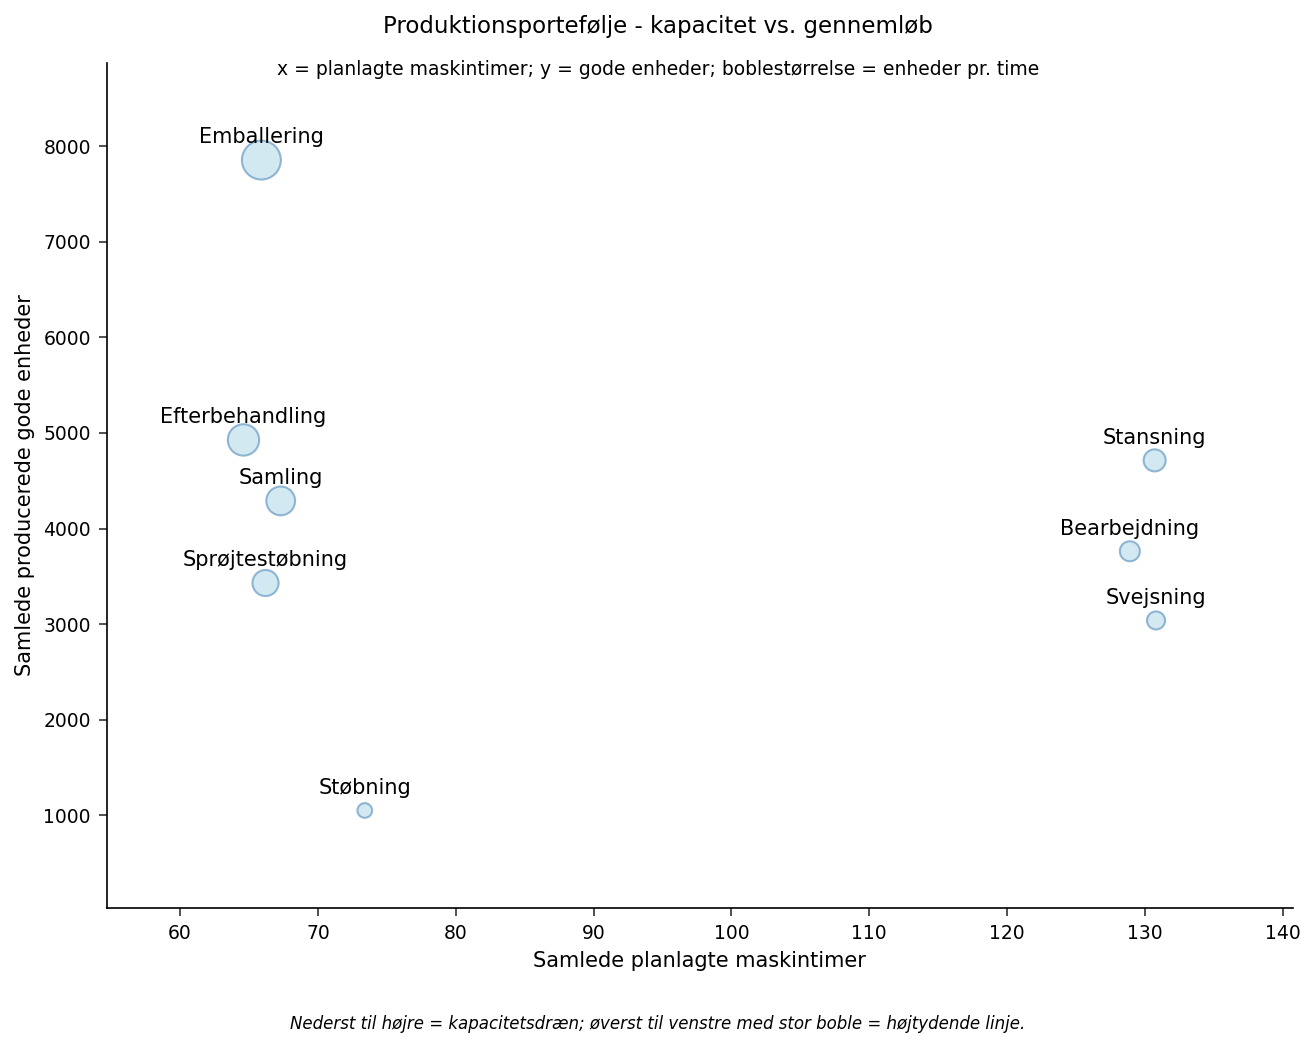

In [4]:
TITEL 'Produktionsportefølje - kapacitet vs. gennemløb';
title2 'x = planlagte maskintimer; y = gode enheder; boblestørrelse = enheder pr. time';
footnote JUSTIFY=LEFT
    'Nederst til højre = kapacitetsdræn; øverst til venstre med stor boble = højtydende linje.';

PROCEDURE SGPLOT data=work.line_total;
    bubble x=total_capacity y=good_units size=units_per_hr /
        DATALABEL=product_line
        fillattrs=(color=cx2C5F8A)
        TRANSPARENCY=0.45;
    XAXIS MÆRKAT='Samlede planlagte maskintimer';
    YAXIS MÆRKAT='Samlede producerede gode enheder';
KØR;

TITEL; title2; footnote;


## 5. Gennemløb efter linje, opdelt efter fabrik

For at se, hvordan hver linjes output fordeler sig på tværs af de tre fabrikker, stabler et `VBAR product_line / response=good_units group=plant`-diagram fabriksbidragene inden i hver søjle. Dette er segmenteringsvisningen: den viser både den samlede højde (gode enheder pr. linje) og fabriksfordelingen inden i hver søjle, så man kan få øje på linjer, hvor én fabrik dominerer outputtet.

                                 Gode enheder efter produktlinje, stablet efter fabrik                                  
                              Søjlehøjde = samlede gode enheder; segmenter = fabriksbidrag                              




NOTE: Option TITLE changed to Gode enheder efter produktlinje, stablet efter fabrik.
NOTE: Option TITLE2 changed to Søjlehøjde = samlede gode enheder; segmenter = fabriksbidrag.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


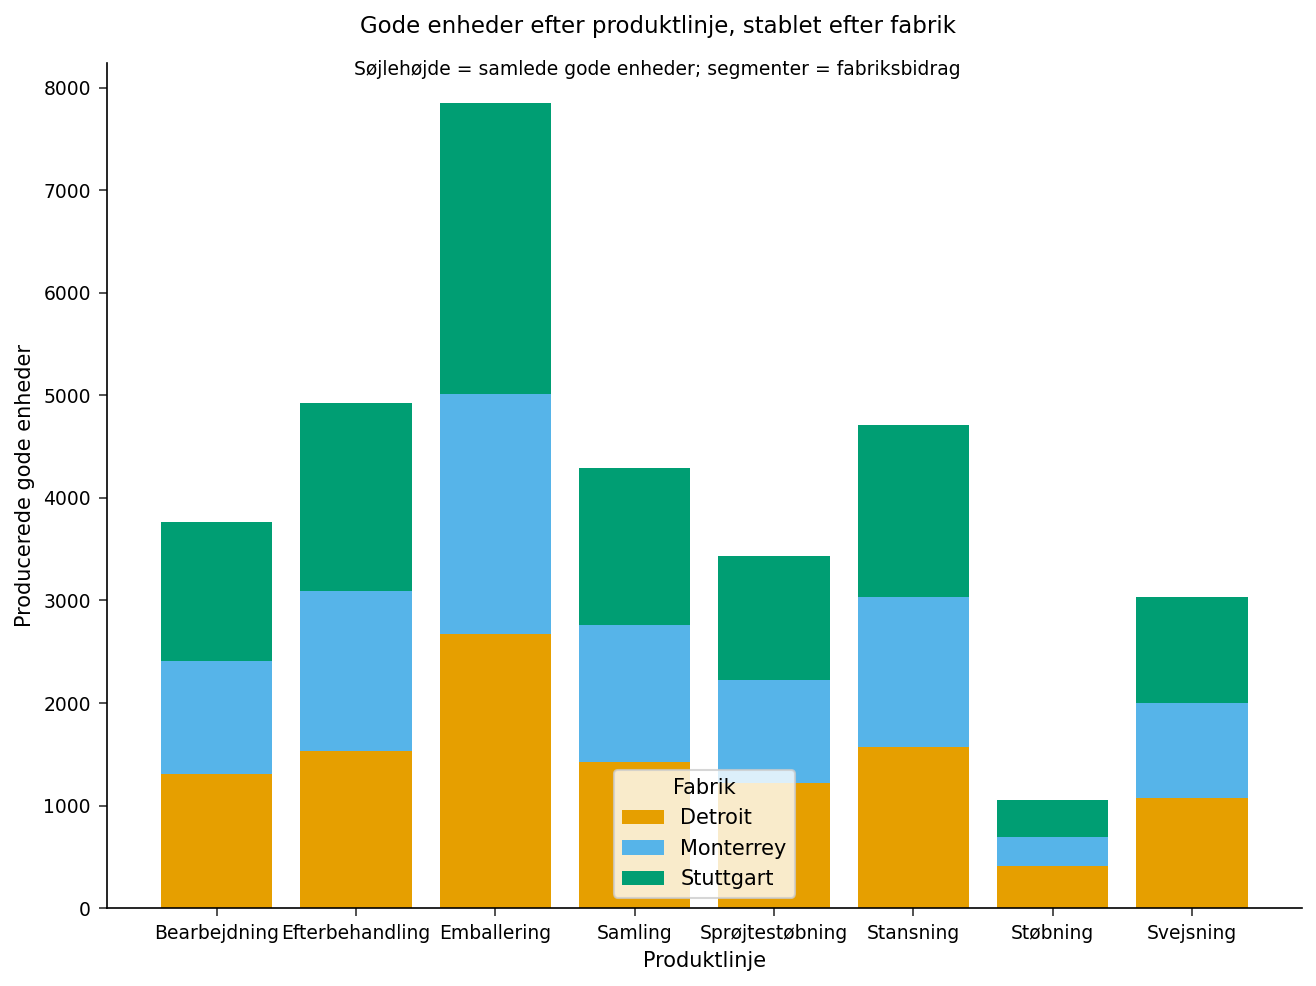

In [5]:
TITEL 'Gode enheder efter produktlinje, stablet efter fabrik';
title2 'Søjlehøjde = samlede gode enheder; segmenter = fabriksbidrag';

PROCEDURE SGPLOT data=work.line_capacity;
    VBAR product_line / RESPONSE=good_units
        GROUP=plant
        GROUPDISPLAY=stack;
    XAXIS MÆRKAT='Produktlinje' fitpolicy=ROTATE;
    YAXIS MÆRKAT='Producerede gode enheder';
    keylegend / TITEL='Fabrik' position=bottom;
KØR;

TITEL; title2;


## 6. Produktivitets-drill-down for enkelt fabrik (WHERE)

Vandrette søjler (`HBAR`) passer til lange produktlinje-etiketter. Et `WHERE`-udtryk afgrænser til Stuttgart-fabrikken, og søjlerne tegnes for `units_per_hr`, så diagrammet rangerer Stuttgarts linjer efter produktivitet. Fordi inputtet er sorteret stigende efter rate, ligger den mindst produktive linje nederst og den mest produktive øverst.

                                 Stuttgart fabrik - linjer rangeret efter produktivitet                                 


Søjlelængde = gode enheder pr. maskintime (drill-down for enkelt fabrik).



NOTE: Option TITLE changed to Stuttgart fabrik - linjer rangeret efter produktivitet.
NOTE: Option FOOTNOTE changed to Søjlelængde = gode enheder pr. maskintime (drill-down for enkelt fabrik)..
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


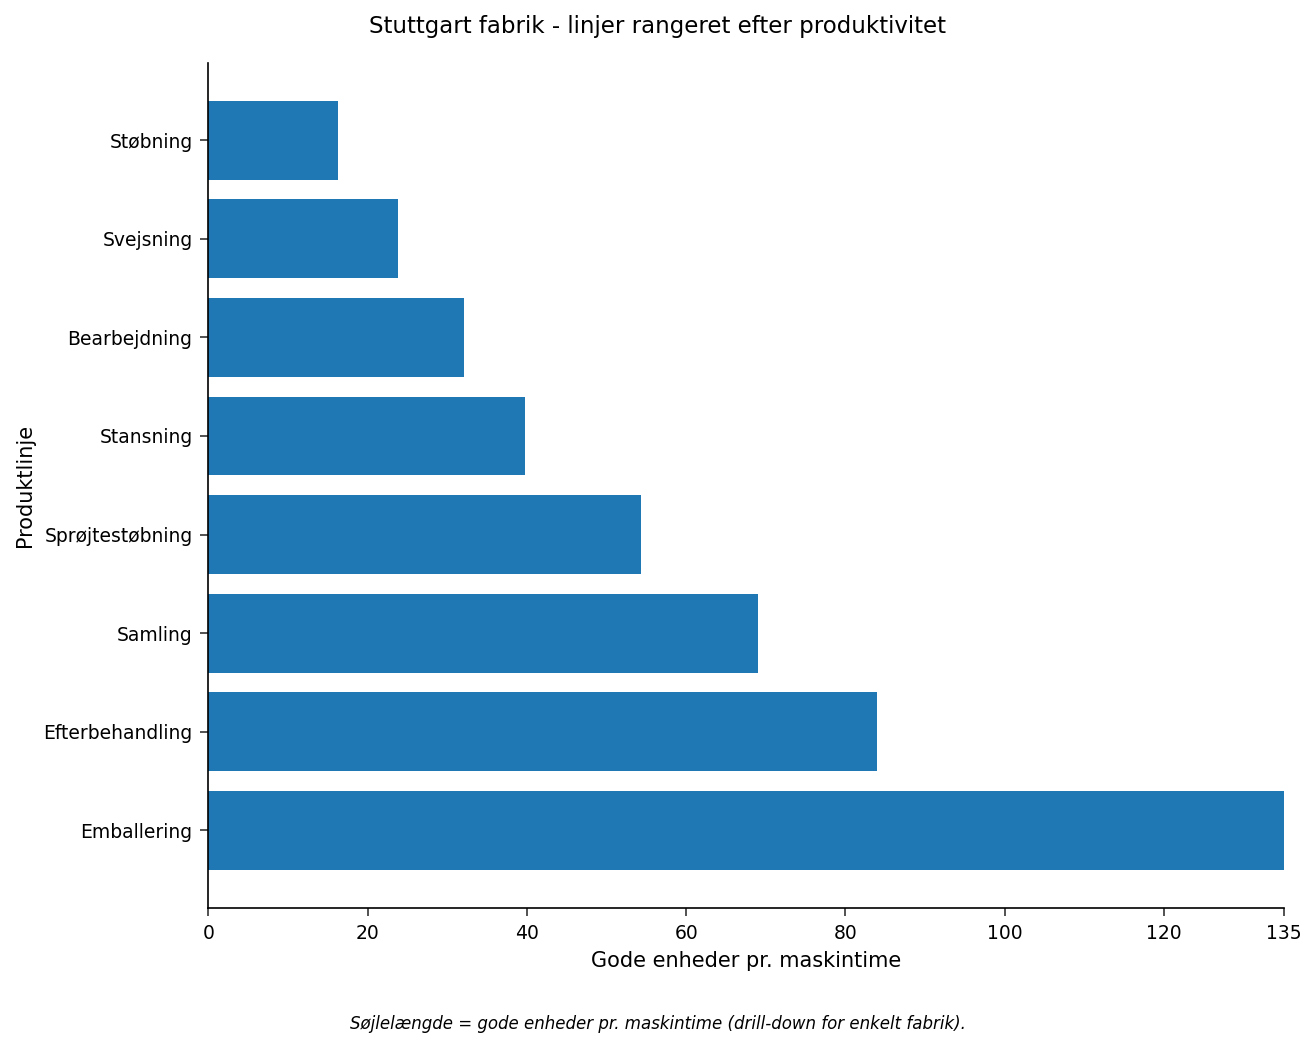

In [6]:
TITEL 'Stuttgart fabrik - linjer rangeret efter produktivitet';
footnote JUSTIFY=LEFT 'Søjlelængde = gode enheder pr. maskintime (drill-down for enkelt fabrik).';

PROCEDURE SGPLOT data=work.line_capacity;
    HVOR plant = 'Stuttgart';
    HBAR product_line / RESPONSE=units_per_hr
        CATEGORYORDER=respasc
        fillattrs=(color=cx28A745);
    XAXIS MÆRKAT='Gode enheder pr. maskintime';
    YAXIS MÆRKAT='Produktlinje';
KØR;

TITEL; footnote;


## 7. Side-om-side fabrikssammenligning (klyngesøjler)

For at sammenligne de tre fabrikker linje for linje tegner et klyngesøjlediagram (`GROUPDISPLAY=CLUSTER`) Detroit, Monterrey og Stuttgart som tilstødende søjler inden for hver produktlinje. Dette er æble-til-æble-fabriksvisningen: for enhver linje kan man aflæse, hvilken fabrik der producerede flest gode enheder, hvilket gør fabrikkernes effektivitetsforskelle (Stuttgart højest, Monterrey lavest) direkte synlige.

                                   Gode enheder efter linje og fabrik - side om side                                    
                             Klyngesøjler: én søjle pr. fabrik inden for hver produktlinje                              




NOTE: Option TITLE changed to Gode enheder efter linje og fabrik - side om side.
NOTE: Option TITLE2 changed to Klyngesøjler: én søjle pr. fabrik inden for hver produktlinje.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot3.svg
NOTE: ODS Graphics is OFF.


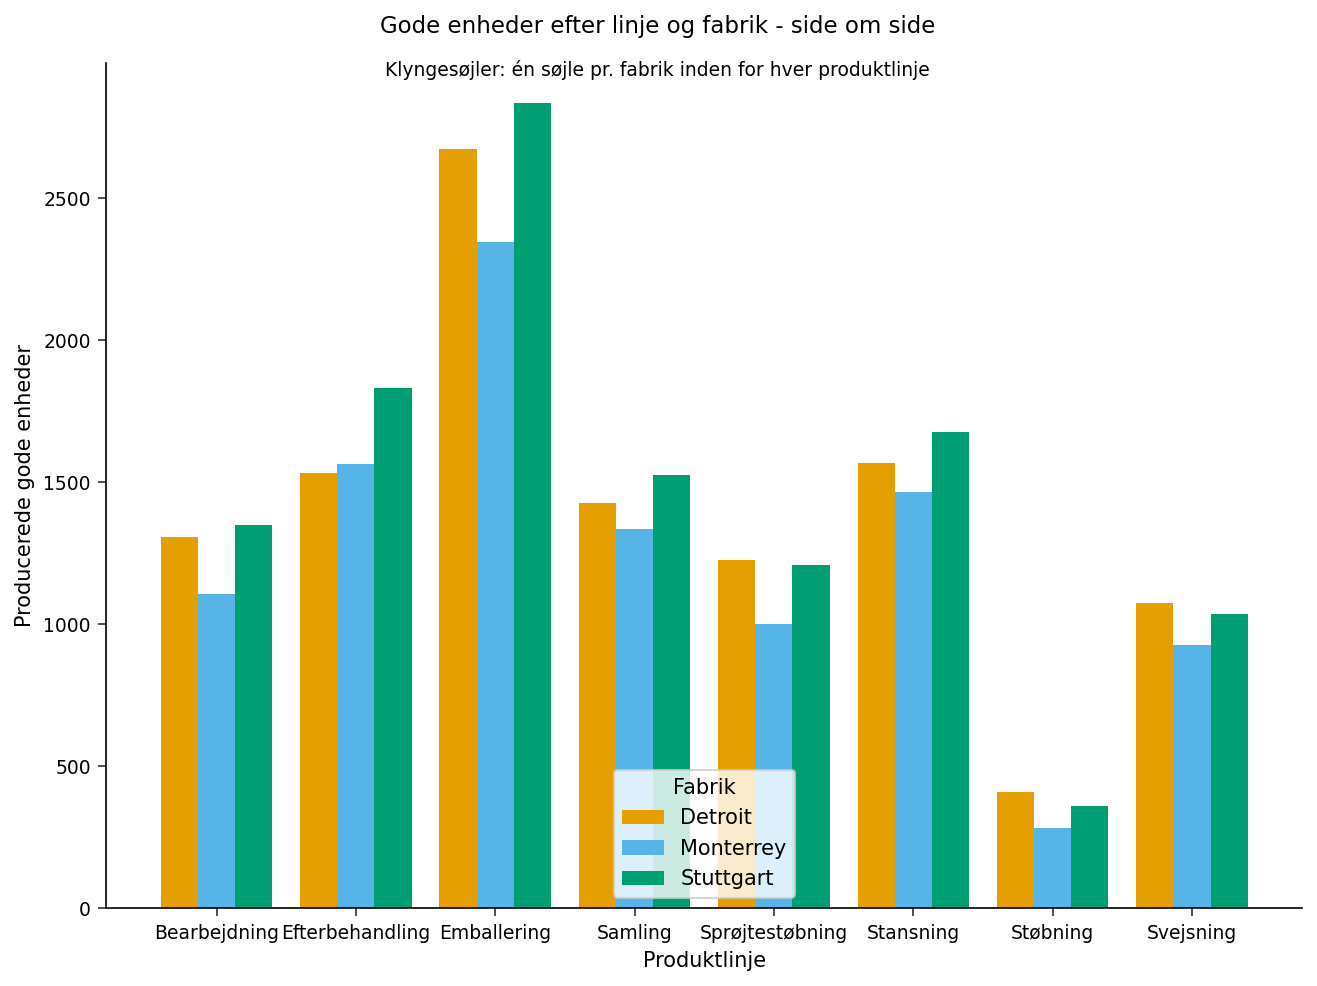

In [7]:
TITEL 'Gode enheder efter linje og fabrik - side om side';
title2 'Klyngesøjler: én søjle pr. fabrik inden for hver produktlinje';

PROCEDURE SGPLOT data=work.line_capacity;
    VBAR product_line / RESPONSE=good_units
        GROUP=plant
        GROUPDISPLAY=CLUSTER;
    XAXIS MÆRKAT='Produktlinje' fitpolicy=ROTATE;
    YAXIS MÆRKAT='Producerede gode enheder';
    keylegend / TITEL='Fabrik' position=bottom;
KØR;

TITEL; title2;

ODS GRAPHICS OFF;
ODS html CLOSE;


## Fortolkning

At plotte kapacitet og gennemløb på de samme akser afslører en sammenhæng, et endimensionalt søjlediagram ville skjule. **Støbning** er porteføljens klareste kapacitetsdræn: i produktivitetsrangeringen ligger den nederst med **14.3 gode enheder pr. maskintime**, og i boble-plottet falder den til nederst til venstre som en lille boble — den trækker **10.1%** af de samlede planlagte timer, men returnerer kun **3.2%** af de gode enheder (den har også det laveste udbytte, ~91%, på grund af sin høje kasseringsandel). Den er den oplagte kandidat til kaizen for cyklustid og kasseringsreduktion. I den modsatte ende er **Emballering** den mest fremtrædende højtydende linje med **119.2 enheder pr. maskintime** — en stor boble højt på gennemløbsaksen, der omdanner **9.1%** af kapaciteten til **23.8%** af alle gode enheder; at beskytte dens driftstid giver et uforholdsmæssigt stort output. **Efterbehandling** (76.3 enheder/time) og **Samling** (63.7) følger samme højtydende mønster.

Mønsteret er systematisk: de fire langsomme, kapacitetssultne opstrømslinjer — Støbning, Svejsning (23.2 enheder/time), Bearbejdning (29.2) og Stansning (36.1) — forbruger tilsammen omkring **64%** af de planlagte timer, men leverer kun omkring **38%** af de gode enheder, mens de fire hurtige nedstrømslinjer overleverer i forhold til de timer, de trækker. Den fabriksstablede visning og de side-om-side-klyngesøjler viser fabriksdimensionen bag dette: **Stuttgart** kører varmest med **49.9 gode enheder pr. maskintime**, **Detroit** ligger i midten med **44.9**, og **Monterrey** halter bagefter med **41.6** — i overensstemmelse med Monterreys højere modellerede nedetid. Operationelt peger dette på at omfordele planlagte timer mod de højtydende nedstrømslinjer og benchmarke Monterreys nedetid mod Stuttgarts praksis.

*Kun syntetiske data — tallene illustrerer todimensional kapacitet-vs-gennemløb-visualisering med PROC SGPLOT, ikke faktisk fabriksydeevne.*